In [1]:
from bidr_relight.main import relight_content_image
import numpy as np
import torch

from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import os
from bidr_relight.isd_estimator.unet import ResNet50UNet

%load_ext autoreload
%autoreload 2


In [2]:
# ISD model
isd_model_path = "../weights/unet.pth"
isd_model = ResNet50UNet(
    in_channels=3,
    out_channels=3,
    pretrained=True,
    checkpoint=isd_model_path,
    se_block=True,
    dropout=0.0,
)

INFO: Initializing ResNet50UNet | in_channels=3, out_channels=3, pretrained=True, checkpoint=../weights/unet.pth, se_block=True
INFO: Loading ResNet50 weights from checkpoint: ../weights/unet.pth


INFO: ResNet50UNet Parameter Summary (Top-Level Modules):
INFO: --------------------------------------------------------------------------------
INFO: in_conv                   | Total: 9536                 | Trainable: 9,536
INFO: maxpool                   | Total: 0                    | Trainable: 0
INFO: enc1                      | Total: 215808               | Trainable: 215,808
INFO: enc2                      | Total: 1219584              | Trainable: 1,219,584
INFO: enc3                      | Total: 7098368              | Trainable: 7,098,368
INFO: enc4                      | Total: 14964736             | Trainable: 14,964,736
INFO: up4                       | Total: 16551456             | Trainable: 16,551,456
INFO: up3                       | Total: 2959120              | Trainable: 2,959,120
INFO: up2                       | Total: 740232               | Trainable: 740,232
INFO: up1                       | Total: 148420               | Trainable: 148,420
INFO: up0            

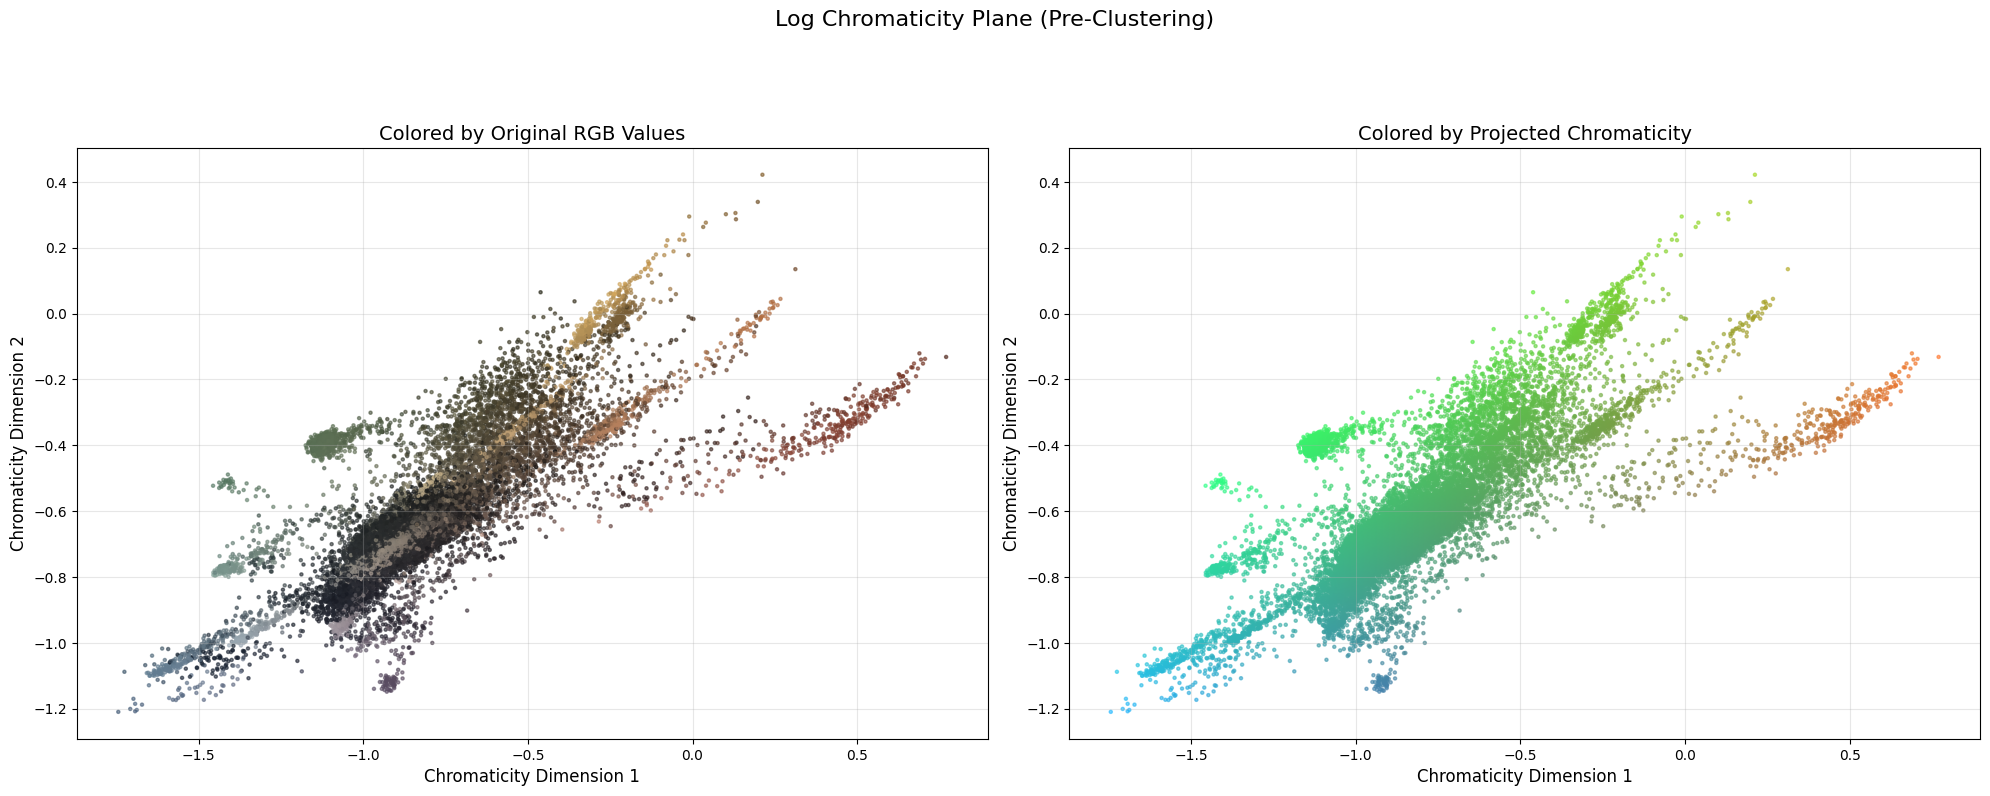

INFO: Greedy clustering: 39 clusters with radius=0.2


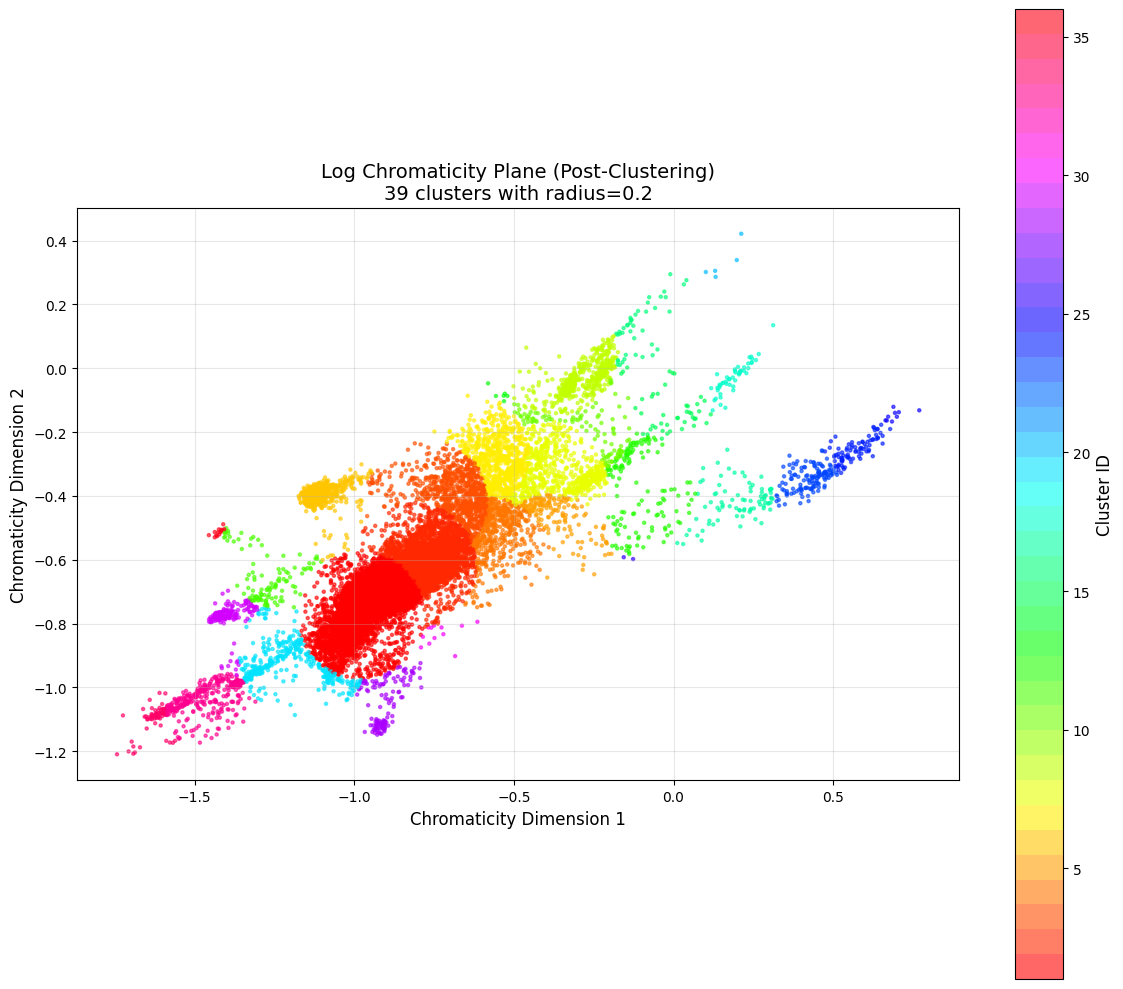

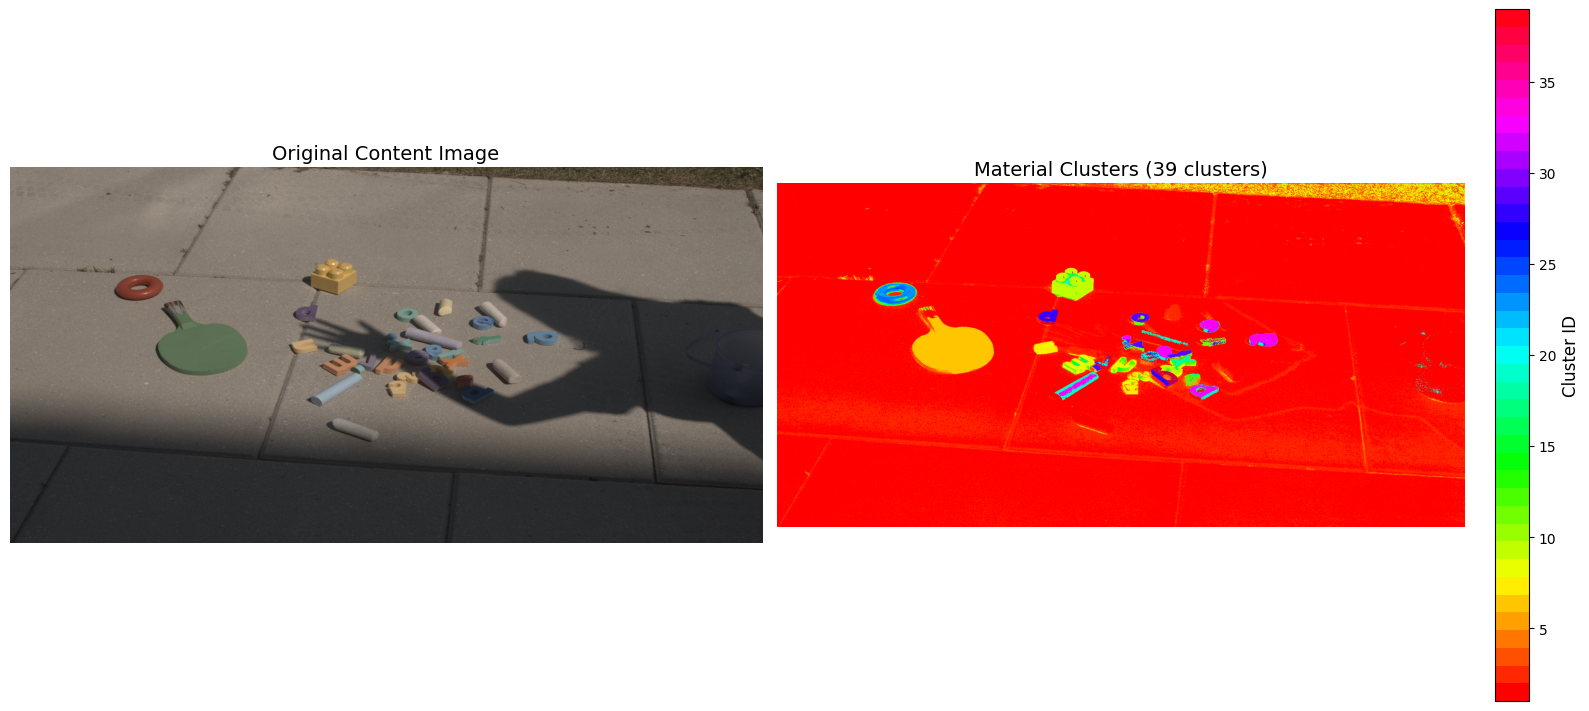

INFO: Estimated illumination vector norm 4.153867456250531
INFO: Estimated dark and bright points for 39 material clusters
INFO: Average Style ISD: [0.63431305 0.58443534 0.5060457 ]. Average Content ISD: [0.6315636 0.5815025 0.512818 ]
INFO: Pivoted all pixels for each material cluster.


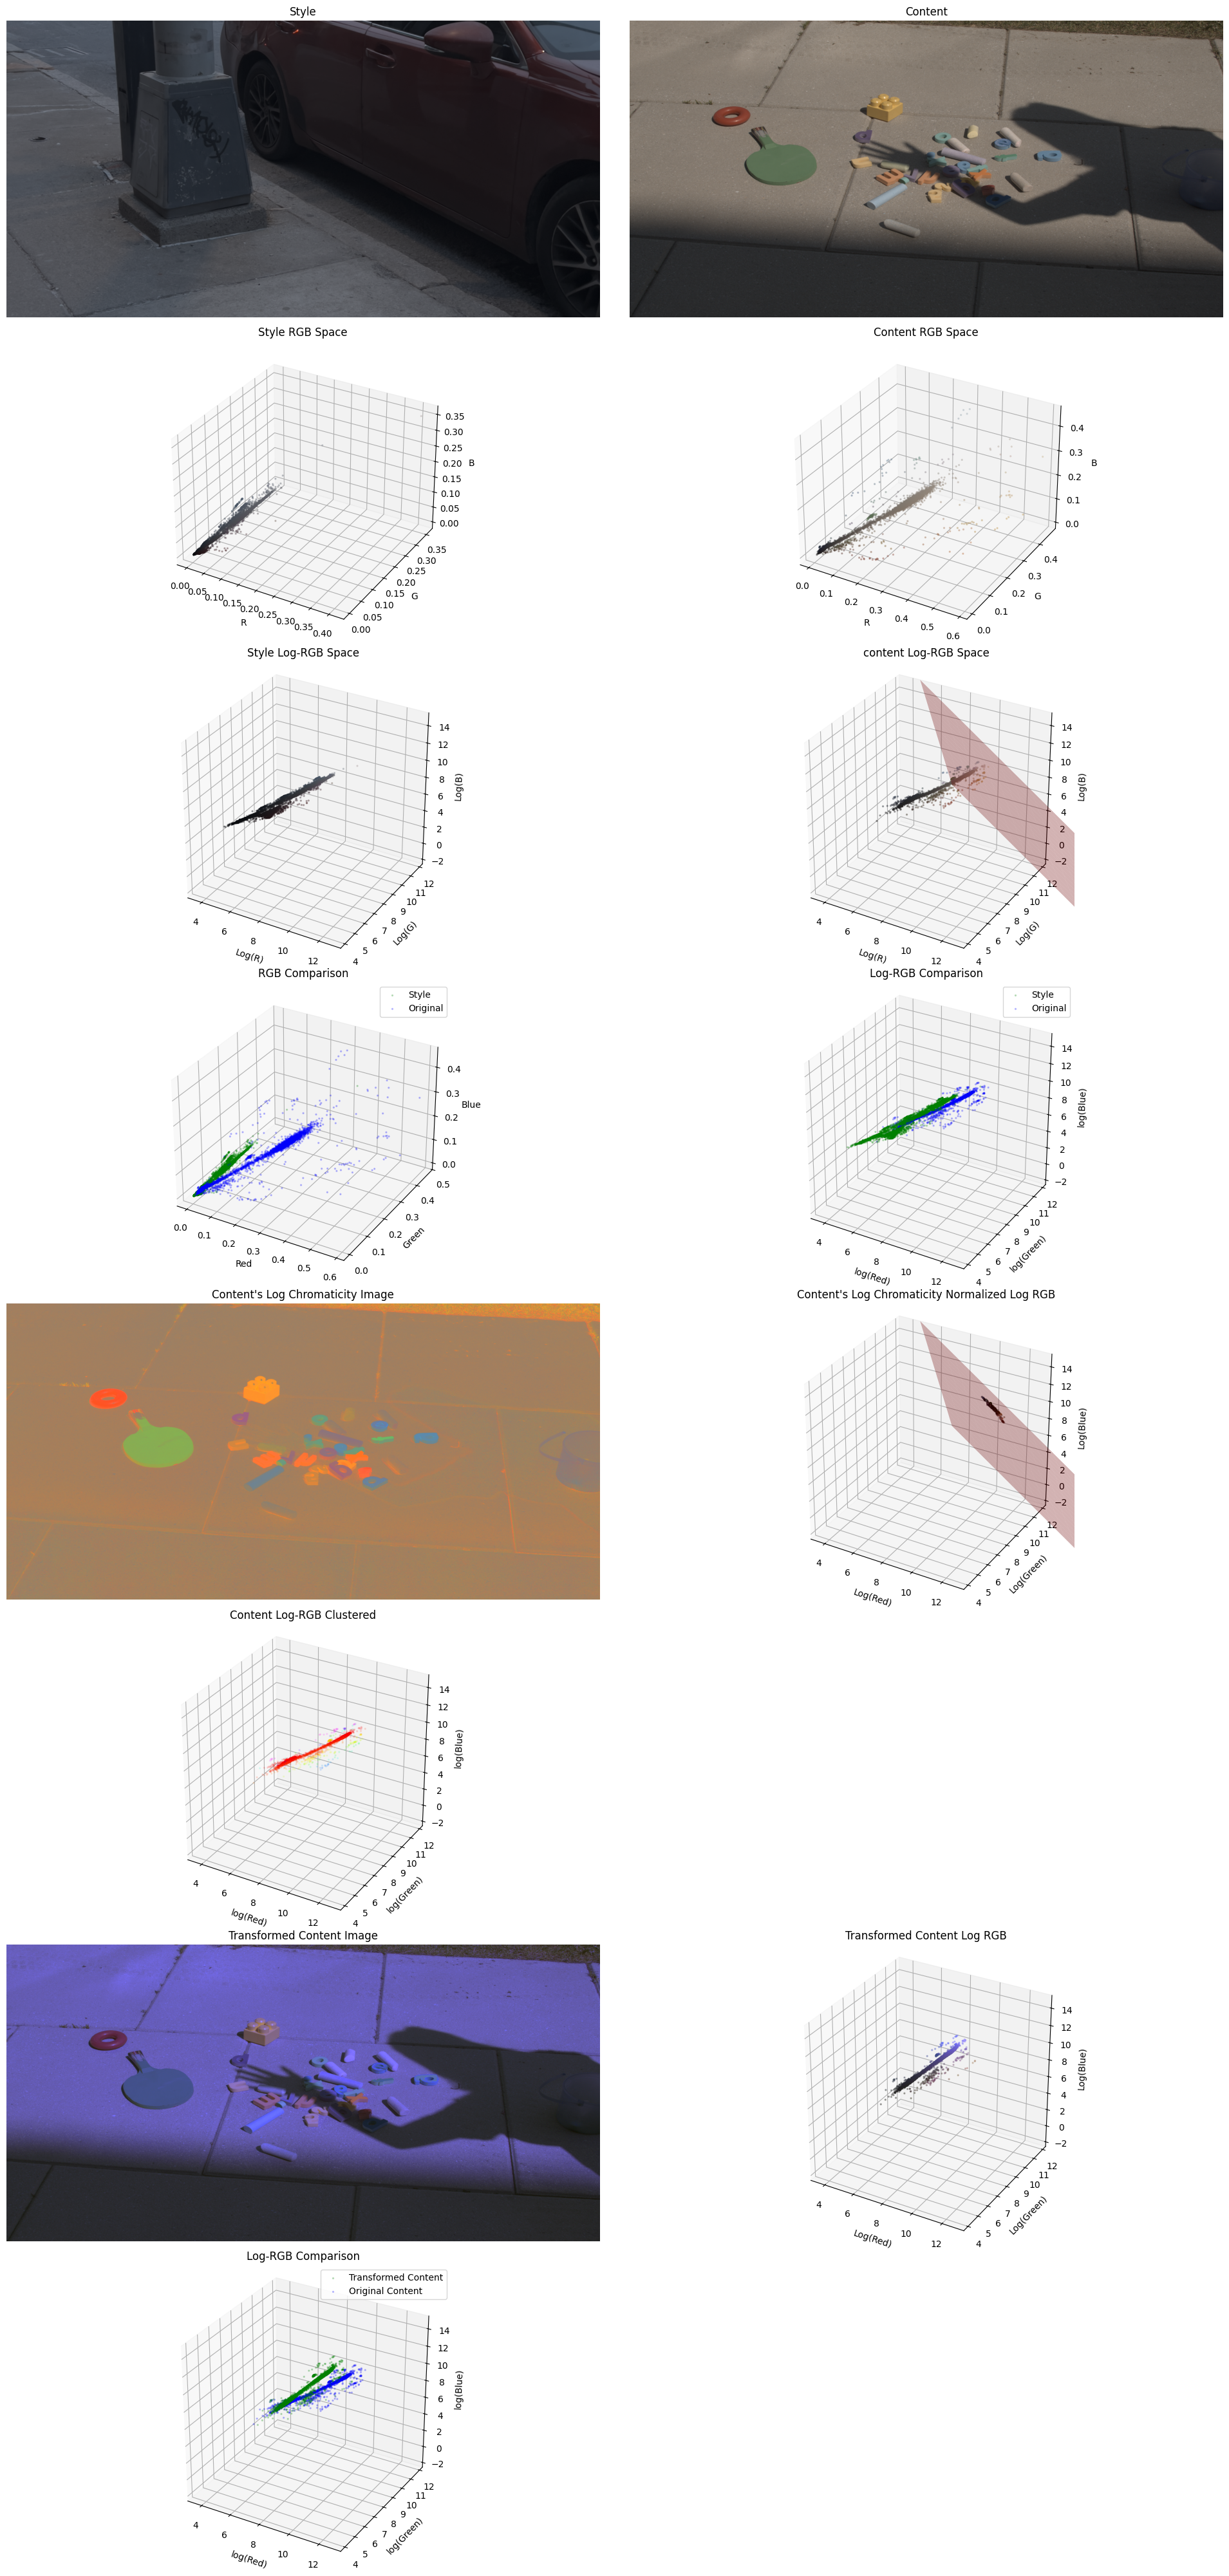

In [4]:
_ = relight_content_image(
    # content_path="../data/compressed/bottle_sun.tiff",
    # style_path="../data/compressed/bottle_cloudy.tiff",
    # content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    # style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    # style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    # content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 001123.tiff",
    style_path="../data/adh/IMG_8209.tiff",
    isd_model=isd_model,
    output_path="../data/target.png",
    shading_only=True,
    compression_factor=0.5,
    resize_scale=1 / 3,
    view_isd=False,  # see log rgb perpendicular to isd. should look similar to log chroma plane from max.
    clustering_method="greedy",  # greedy, kmeans
    # n_clusters=3,d
    bin_radius=0.2,
    rot_percent=100.0,  # either change this or rot_angle, not both.
    rot_angle=np.deg2rad(-20.0),
    # log_transl=np.ones(3) * -1.0,
    length_scale=1.0,
    always_use_global_illum_norm=False,
)